<style>
.jp-RenderedHTMLCommon,
.text_cell_render {
  font-family: medium-content-serif-font, Georgia, Cambria, "Times New Roman", Times, serif;
  font-size: 17px;
  line-height: 1.65;
  color: #1f2328;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.text_cell_render h1,
.text_cell_render h2,
.text_cell_render h3 {
  font-family: sohne, "Helvetica Neue", Helvetica, Arial, sans-serif;
  color: #111;
}
.jp-RenderedHTMLCommon h1,
.text_cell_render h1 {
  font-size: 2.6rem;
  letter-spacing: -0.03em;
}
.jp-RenderedHTMLCommon h2,
.text_cell_render h2 {
  margin-top: 1.8em;
}
</style>

# Expediente C. Contratación atípica

Data Analytics | Semanas 7–8 | 2026-2

Este notebook acompaña la lectura ¿Qué puede decir realmente un contrato público?

Afirmación que se investigará:

Algunas entidades presentan patrones contractuales diferentes al resto que justifican una revisión adicional.

Este expediente utiliza un único archivo: `data/secop_recorte.csv`.

Durante la primera semana se construyen tres evidencias y se documentan tres decisiones de preparación. En la segunda semana se incorpora una objeción y se revisa si la conclusión inicial se mantiene.

El objetivo es que cada cifra utilizada en la conclusión pueda localizarse en el notebook y que el alcance de la afirmación corresponda a lo que realmente muestran los datos.


## Preparar los datos

Ubique el notebook junto a la carpeta `data`.

```text
Expediente_C.ipynb
data/
└── secop_recorte.csv
```

No es necesario descargar datos, seleccionar un equipo ni modificar filtros.


In [6]:
%pip install numpy pandas matplotlib

In [12]:
from pathlib import Path
from statistics import NormalDist
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_FILE = Path("data") / "secop_recorte.csv"

if not DATA_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_recorte.csv.")

df_raw = pd.read_csv(DATA_FILE, dtype=str)

print("Archivo:", DATA_FILE.name)
print("Filas:", f"{len(df_raw):,}")
print("Columnas:", df_raw.shape[1])


Archivo: secop_recorte.csv
Filas: 50,000
Columnas: 85


### Criterio previo del equipo
Consideraremos indicio de atipicidad estadística en una entidad:
1. Una proporción de contratación directa sobre su total claramente mayor que la de sus pares.
2. Una concentración temporal alta de firmas (por ejemplo, un porcentaje elevado de sus contratos firmados en un solo mes) frente a sus pares.

Pares: entidades del mismo orden (territorial, nacional o corporación autónoma) con al menos 30 contratos en el recorte.

Un patrón atípico se leerá como criterio para priorizar una revisión, no como evidencia de irregularidad: puede tener explicaciones legítimas, como la naturaleza misional de la entidad o un régimen de contratación especial.

## Comprender el archivo antes de analizarlo

Cada fila de `secop_recorte.csv` representa un contrato incluido en el conjunto asignado al equipo. El archivo no corresponde a todo SECOP II, sino a una parte previamente seleccionada para la actividad.

La columna `ciudad`, cuando está disponible, identifica la ciudad de registro de la entidad que publica el contrato. No debe interpretarse automáticamente como el lugar físico donde se ejecutó el servicio, la obra o el suministro.

Las siguientes conversiones permiten trabajar con valores y fechas sin eliminar registros.


In [13]:
df = df_raw.copy()

for column in ["valor_del_contrato", "dias_adicionados"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

if {
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
}.issubset(df.columns):
    df["duracion_dias"] = (
        df["fecha_de_fin_del_contrato"]
        - df["fecha_de_inicio_del_contrato"]
    ).dt.days

if {"valor_del_contrato", "duracion_dias"}.issubset(df.columns):
    months = df["duracion_dias"] / 30.44
    df["valor_mensual_equivalente"] = (
        df["valor_del_contrato"] / months.where(months > 0)
    )

sample_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "valor_del_contrato",
        "fecha_de_firma",
    ]
    if c in df.columns
]

df[sample_columns].head()


,id_contrato,nombre_entidad,ciudad,proveedor_adjudicado,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato,fecha_de_firma
0,CO1.PCCNTR.6994937,DANE - TERRITORIAL CENTRO ORIENTE,Bucaramanga,KAREN ANDREA SILVA DUARTE,Prestación de servicios,Contratación directa,6190750.0,2024-11-06
1,CO1.PCCNTR.7964038,METROLINEA S.A,Bucaramanga,servicios electroindustriales arg de santander...,Prestación de servicios,Contratación régimen especial,131589110.0,2025-06-10
2,CO1.PCCNTR.8395876,"INSTITUTO PARA EL FOMENTO DEL DEPORTE, LA RECR...",Barrancabermeja,CESAR ANDRES SIERRA BELTRAN,Prestación de servicios,Contratación directa,6250000.0,2025-10-01
3,CO1.PCCNTR.6217730,UNIDAD PRESTADORA DE SALUD SANTANDER,Bucaramanga,TATIANA ANDREA PLATA CEPEDA,Prestación de servicios,Contratación directa,11821128.0,2024-05-14
4,CO1.PCCNTR.8589375,DEPARTAMENTO DE SANTANDER,Bucaramanga,LUZ JEANETH ROJAS TARAZONA,Prestación de servicios,Contratación directa,46400000.0,2025-11-13


### Respuestas a "Antes de seguir"

**1. ¿Qué representa una fila?**
Cada fila es un contrato registrado en SECOP II dentro del recorte asignado (Santander, 2024-2025). El archivo tiene 50.000 filas y 50.000 identificadores de contrato distintos, así que contar filas equivale a contar contratos, no personas ni proveedores.

**2. ¿Qué información permite identificar a la entidad y al proveedor?**
La entidad se identifica con `nombre_entidad` y con su NIT (`nit_entidad`). El proveedor se identifica con `proveedor_adjudicado` (nombre) y `documento_proveedor` (número de documento). El documento es más confiable que el nombre, porque un mismo nombre puede escribirse de varias formas.

**3. ¿Qué variable monetaria aparece en el archivo?**
`valor_del_contrato`, el valor total registrado del contrato. El archivo también trae otras columnas de dinero (como `valor_pagado` y `valor_facturado`), pero el análisis usa el valor total.

**4. ¿Qué variable o columna necesita comprender mejor?**
`ciudad`. Es la ciudad donde está registrada la entidad que publica el contrato, no necesariamente donde se ejecuta el trabajo. Además, muchas filas dicen "No Definido", un dato faltante que no aparece como vacío. Antes de usarla, hay que definir cómo tratarlo.


## Primera semana: describir el conjunto asignado

La primera revisión se concentra en `valor_del_contrato`. Se estudiará una variable por separado antes de introducir comparaciones entre grupos.

La media, la mediana y los percentiles no responden exactamente la misma pregunta. Si la distribución contiene unos pocos contratos de valor muy alto, la media puede alejarse considerablemente de la mediana.


In [14]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = pd.Series({
    "contratos con valor registrado": len(contract_value),
    "media": contract_value.mean(),
    "mediana": contract_value.median(),
    "percentil 25": contract_value.quantile(0.25),
    "percentil 75": contract_value.quantile(0.75),
    "percentil 90": contract_value.quantile(0.90),
    "mínimo": contract_value.min(),
    "máximo": contract_value.max(),
    "contratos con valor 0": int((contract_value == 0).sum()),
})

value_summary.to_frame("resultado")


,resultado
contratos con valor registrado,5.000000e+04
media,9.906600e+07
mediana,1.500000e+07
percentil 25,8.775000e+06
percentil 75,2.700000e+07
percentil 90,4.986686e+07
mínimo,0.000000e+00
máximo,2.000000e+11
contratos con valor 0,2.790000e+02


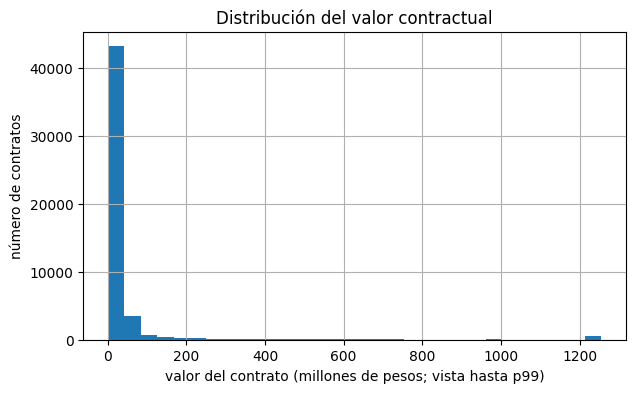

In [15]:
upper_view = contract_value.quantile(0.99)

plt.figure(figsize=(7, 4))
(contract_value.clip(upper=upper_view) / 1_000_000).hist(bins=30)
plt.xlabel("valor del contrato (millones de pesos; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title("Distribución del valor contractual")
plt.show()


### Deténgase y revise


**1. ¿La media y la mediana son semejantes o muy diferentes?**
Muy diferentes. La media es de unos $99,1 millones y la mediana de $15 millones: la media es cerca de 6,6 veces la mediana.

**2. ¿Cuál describe mejor un contrato típico?**
La mediana. Aproximadamente el 94 % de los contratos vale menos que la media, así que la media no representa al contrato típico: la arrastran unos pocos contratos de valor muy alto (el máximo es de $200.000 millones).

**3. ¿Qué muestra el histograma sobre la forma de la distribución?**
Es muy asimétrica hacia la derecha: casi todos los contratos se agrupan en los valores bajos (la primera barra reúne cerca del 86 %) y hay una cola larga de contratos de valor muy alto.

**4. ¿Por qué limitar la escala al percentil 99 no equivale a eliminar esos contratos?**
Porque el límite solo cambia lo que se dibuja: los valores por encima del percentil 99 se muestran en el borde del gráfico. El resumen numérico se calculó antes, con todos los contratos, y ninguno se eliminó de los datos.


## Revisar la calidad antes de preparar los datos

Un faltante, un valor en cero, una repetición o un valor extremo no se elimina automáticamente. Primero debe establecerse si afecta la pregunta que se quiere responder.

La siguiente revisión muestra aspectos que pueden modificar las conclusiones.


In [16]:
quality_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "documento_proveedor",
        "valor_del_contrato",
        "fecha_de_inicio_del_contrato",
        "fecha_de_fin_del_contrato",
        "duracion_dias",
    ]
    if c in df.columns
]

quality = pd.DataFrame({
    "faltantes": df[quality_columns].isna().sum(),
    "porcentaje_faltante": (df[quality_columns].isna().mean() * 100).round(1),
    "valores_unicos": df[quality_columns].nunique(dropna=True),
})

display(quality)

if "id_contrato" in df.columns:
    print(
        "IDs de contrato repetidos:",
        int(df["id_contrato"].duplicated(keep=False).sum())
    )

q1, q3 = df["valor_del_contrato"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

print("Contratos con valor 0:", int((df["valor_del_contrato"] == 0).sum()))
print(
    "Posibles valores extremos según 1.5 × IQR:",
    int((df["valor_del_contrato"] > upper_iqr).sum())
)

if "duracion_dias" in df.columns:
    invalid_duration = (
        df["duracion_dias"].isna()
        | (df["duracion_dias"] <= 0)
    ).sum()
    print("Duraciones faltantes o no positivas:", int(invalid_duration))


,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0.0,50000
nombre_entidad,0,0.0,230
ciudad,0,0.0,76
proveedor_adjudicado,0,0.0,27595
documento_proveedor,2,0.0,27595
valor_del_contrato,0,0.0,13795
fecha_de_inicio_del_contrato,139,0.3,706
fecha_de_fin_del_contrato,0,0.0,1153
duracion_dias,139,0.3,596


IDs de contrato repetidos: 0
Contratos con valor 0: 279
Posibles valores extremos según 1.5 × IQR: 4483
Duraciones faltantes o no positivas: 387


### Comprobar si una decisión cambia el resultado

Antes de decidir qué hacer con los valores en cero o con los contratos más altos, conviene observar cuánto cambia una estadística sencilla.

La siguiente comparación no prescribe una limpieza. Su función es mostrar si la mediana resulta sensible a tres formas distintas de preparar el valor contractual.


In [17]:
medians = {}

all_values = df["valor_del_contrato"].dropna()
if len(all_values):
    medians["sin retirar ceros"] = all_values.median()

positive_values = df.loc[
    df["valor_del_contrato"] > 0,
    "valor_del_contrato"
].dropna()

if len(positive_values):
    medians["solo valores positivos"] = positive_values.median()

if len(positive_values):
    p99 = positive_values.quantile(0.99)
    below_p99 = positive_values[positive_values <= p99]
    medians["positivos, sin el 1 % superior"] = below_p99.median()

pd.Series(medians, name="mediana_valor")


,mediana_valor
sin retirar ceros,15000000.0
solo valores positivos,15000000.0
"positivos, sin el 1 % superior",15000000.0


### Tres decisiones de preparación

Documente tres decisiones que realmente se desprendan de sus datos. Para cada una, responda:

1. ¿Qué situación encontró?
2. ¿Qué tratamiento decidió aplicar?
3. ¿Qué salida del notebook respalda la decisión?
4. ¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?

No es necesario que todos los equipos adopten las mismas decisiones.


### Decisiones de preparación del equipo

**Decisión 1. Conservar los contratos con valor 0.**

1. Situación: 279 contratos tienen valor 0 (salida de la revisión de calidad y del resumen del valor contractual).
2. Tratamiento: no se eliminan ni se reemplazan; se mantienen en los datos.
3. Salida que lo respalda: la comparación de medianas da $15.000.000 tanto sin retirar ceros como con solo valores positivos, así que los ceros no alteran la mediana.
4. Qué podría cambiar si fuera equivocada: los ceros no suman nada a los totales, pero sí cuentan como contratos y podrían bajar el valor mediano de alguna entidad. La mediana general no cambiaría.

**Decisión 2. Conservar los valores extremos.**

1. Situación: 4.483 contratos superan el límite de 1,5 × IQR y el máximo es de 200.000 millones, frente a un percentil 90 de unos 49,9 millones (resumen del valor contractual y revisión de calidad).
2. Tratamiento: no se eliminan; para describir un contrato típico se usa la mediana y no la media.
3. Salida que lo respalda: la comparación de medianas da $15.000.000 también sin el 1 % superior, así que la mediana no es sensible a esos contratos.
4. Qué podría cambiar si fuera equivocada: el valor total de las entidades sí incluye esos contratos, y una sola operación grande puede mover el total de una entidad. Las conclusiones basadas en valor total serían las más sensibles.

**Decisión 3. No eliminar los contratos con duración no válida ni usar `duracion_dias` en la comparación de entidades.**

1. Situación: 387 contratos tienen duración faltante o no positiva; 139 (0,3 %) son faltantes, porque falta la fecha de inicio (revisión de calidad).
2. Tratamiento: se conservan las filas; la comparación de entidades usa cantidad de contratos, valor total y valor mediano, que no dependen de la duración.
3. Salida que lo respalda: la tabla de calidad (139 faltantes en `fecha_de_inicio_del_contrato` y en `duracion_dias`) y el conteo de 387 duraciones faltantes o no positivas.
4. Qué podría cambiar si fuera equivocada: la comparación de entidades no cambiaría. Solo se verían afectados cálculos que dependan de la duración, como un valor por mes.

## Expediente C: entidades que se apartan del patrón general

Se compararán las entidades por cantidad de contratos, valor total y valor mediano.

Que una entidad sobresalga frente al resto significa únicamente que merece una revisión adicional. La diferencia no constituye por sí sola evidencia de irregularidad.


In [18]:
entities = (
    df.dropna(subset=["nombre_entidad"])
      .groupby("nombre_entidad")
      .agg(
          contratos=("id_contrato", "count"),
          valor_total=("valor_del_contrato", "sum"),
          valor_mediano=("valor_del_contrato", "median"),
      )
)

print("Entidades con mayor número de contratos:")
display(
    entities.sort_values("contratos", ascending=False).head(10)
)

enough_data = entities[entities["contratos"] >= 5]

print("Entidades con al menos cinco contratos y mayor valor mediano:")
display(
    enough_data
    .sort_values("valor_mediano", ascending=False)
    .head(10)
)

if len(enough_data):
    entity_review = enough_data["valor_mediano"].idxmax()
    print("Entidad seleccionada para revisión:", entity_review)
else:
    entity_review = None
    print("No hay entidades con al menos cinco contratos para esta comparación.")


Entidades con mayor número de contratos:


,contratos,valor_total,valor_mediano
nombre_entidad,,,
ALCALDIA DISTRITAL BARRANCABERMEJA,5379,3.856411e+11,10000000.00
MUNICIPIO DE BUCARAMANGA,5104,5.095900e+11,18333333.33
DEPARTAMENTO DE SANTANDER,3787,1.132076e+12,24000000.00
ALCALDIA DE FLORIDABLANCA,2728,2.428004e+11,12250000.00
MUNICIPIO DE PIEDECUESTA,1895,1.288133e+11,15680000.00
SENA REGIONAL SANTANDER Grupo de Apoyo Administrativo Mixto,1529,6.796228e+10,35914307.00
E.S.E. INSTITUTO DE SALUD DE BUCARAMANGA,1522,5.361440e+10,13500000.00
DANE - TERRITORIAL CENTRO ORIENTE,1470,2.172954e+10,9511573.50
CORPORACION AUTONOMA REGIONAL DE SANTANDER+,1454,4.044226e+10,10203258.00


Entidades con al menos cinco contratos y mayor valor mediano:


,contratos,valor_total,valor_mediano
nombre_entidad,,,
MUNICIPIO DE TONA,5,9.964160e+08,2.059630e+08
ALCALDIA CERRITO SANTANDER,7,1.492931e+09,1.711700e+08
ALCALDIA MUNICIPAL DE GALAN,7,9.778476e+08,1.701025e+08
MUNICIPIO FLORIAN SANTANDER,6,1.744123e+09,1.412722e+08
ALCALDIA DE ENCINO,5,4.746129e+08,1.228373e+08
ALCALDIA MUNICIPIO DE LA PAZ,7,8.085423e+08,1.210070e+08
ALCALDIA MUNICIPAL DE PUENTE NACIONAL,15,2.553762e+09,1.181620e+08
ALCALDÍA MUNICIPAL DE SAN JOAQUIN SANTANDER,6,8.432160e+08,1.148430e+08
INSTITUTO COLOMBIANO AGROPECUARIO - ICA SANTANDER,33,3.436850e+09,1.110371e+08


Entidad seleccionada para revisión: MUNICIPIO DE TONA


### Interpretar el resultado

1. ¿Qué entidad sobresale según el criterio utilizado?
2. ¿Sobresale por cantidad, valor total, valor mediano o por varias medidas?
3. ¿Qué explicación podría producir ese patrón sin que exista una irregularidad?
4. ¿Qué comparación adicional sería necesaria antes de emitir una conclusión?




**1. ¿Qué entidad sobresale según el criterio utilizado?**
El Municipio de Tona, que es la entidad con mayor valor mediano entre las que tienen al menos cinco contratos: unos 206 millones, cerca de 14 veces la mediana general de 15 millones.

**2. ¿Sobresale por cantidad, valor total, valor mediano o por varias medidas?**
Solo por valor mediano. Tiene 5 contratos (el mínimo que permite el filtro) y un valor total de unos 996 millones, muy por debajo de las entidades con más contratos, cuyos totales están en los cientos de miles de millones o más. Además, las diez entidades de mayor valor mediano tienen entre 5 y 33 contratos, es decir, muy pocos.

**3. ¿Qué explicación podría producir ese patrón sin que exista una irregularidad?**
Con solo cinco contratos, uno o dos de valor alto bastan para elevar la mediana. Un municipio pequeño puede firmar pocos contratos, pero grandes (por ejemplo, obras o suministros). El resultado puede reflejar el tamaño de esos pocos contratos y no un comportamiento distinto al de otras entidades.

**4. ¿Qué comparación adicional sería necesaria antes de emitir una conclusión?**
Ver de qué son los cinco contratos de Tona y si uno solo explica la mediana, y compararla con entidades pares con más contratos. Además, el criterio previo del equipo (proporción de contratación directa y concentración temporal de firmas frente a pares con al menos 30 contratos) no se calcula en esta celda; habría que aplicarlo antes de concluir.

## Tablero de evidencia de la primera semana

Seleccione tres hallazgos. Para cada uno registre el hallazgo, la cifra o tabla que lo respalda, una interpretación posible y una duda pendiente.

Evite utilizar la palabra irregularidad como conclusión a partir de una diferencia descriptiva.


### Tablero de evidencia (semana 1)

**Tarjeta 1. El contrato típico y el promedio no coinciden**
- Hallazgo: el valor de los contratos es muy asimétrico: unos pocos contratos muy grandes elevan la media.
- Evidencia: media de unos 99,1 millones frente a mediana de 15 millones; percentil 75 de 27 millones, percentil 90 de unos 49,9 millones y máximo de 200.000 millones (resumen del valor contractual y su histograma).
- Interpretación posible: la cola de contratos de valor muy alto arrastra la media, por lo que la mediana describe mejor a un contrato típico.
- Duda pendiente: si esos contratos muy grandes son de naturaleza distinta y deberían analizarse aparte.

**Tarjeta 2. Cantidad de contratos y valor total no coinciden entre entidades**
- Hallazgo: la entidad con más contratos no es la de mayor valor total.
- Evidencia: la Alcaldía Distrital de Barrancabermeja registra 5.379 contratos y el Municipio de Bucaramanga 5.104, más que el Departamento de Santander (3.787), pero este último tiene el mayor valor total, cerca de 1,13 billones (tabla de entidades con mayor número de contratos).
- Interpretación posible: el volumen de contratos y el valor total miden cosas distintas; una entidad puede firmar muchos contratos pequeños o pocos de gran valor.
- Duda pendiente: si esas diferencias reflejan el tamaño y las funciones de cada entidad y no un patrón particular de contratación.

**Tarjeta 3. Una entidad con valor mediano alto y muy pocos contratos**
- Hallazgo: el Municipio de Tona tiene el mayor valor mediano entre las entidades con al menos cinco contratos.
- Evidencia: valor mediano de unos 206 millones con 5 contratos, frente a 15 millones de mediana general; las diez entidades de mayor valor mediano tienen entre 5 y 33 contratos (tabla de entidades con al menos cinco contratos).
- Interpretación posible: con tan pocos contratos, la mediana depende de uno o dos valores altos, así que el resultado puede ser poco estable.
- Duda pendiente: qué contratos componen ese valor y cómo se compara Tona con entidades que tengan más contratos.

## Segunda semana: poner a prueba la conclusión

Objeción de trabajo: una entidad puede parecer atípica porque contrata mediante modalidades diferentes a las del resto.

Antes de ejecutar la siguiente comparación, responda:

1. ¿Qué parte de la conclusión inicial pone en duda esta objeción?
2. ¿Por qué la modalidad de contratación podría explicar parte del patrón?
3. ¿Qué debería comparar para comprobarlo?


In [ ]:
if "modalidad_de_contratacion" not in df.columns:
    raise KeyError("El archivo no contiene modalidad_de_contratacion.")

if entity_review is None:
    print("No se definió una entidad para revisión.")
else:
    entity_by_mode = (
        df[df["nombre_entidad"] == entity_review]
        .groupby("modalidad_de_contratacion")
        .agg(
            contratos=("id_contrato", "count"),
            valor_mediano=("valor_del_contrato", "median"),
        )
        .sort_values("contratos", ascending=False)
    )

    general_by_mode = (
        df.groupby("modalidad_de_contratacion")
          .agg(
              contratos=("id_contrato", "count"),
              valor_mediano=("valor_del_contrato", "median"),
          )
          .sort_values("contratos", ascending=False)
    )

    print("Entidad seleccionada:")
    display(entity_by_mode)

    print("Referencia general por modalidad:")
    display(general_by_mode.head(10))


### Deténgase y revise

1. ¿Parte del patrón inicial cambia al separar por modalidad?
2. ¿La entidad continúa sobresaliendo dentro de modalidades comparables?
3. ¿El hallazgo inicial se mantiene, se debilita o cambia?
4. ¿Qué información adicional necesitaría antes de priorizar una revisión?


## Asociación no significa causalidad

Cuando dos variables cambian conjuntamente, la relación puede tener varias explicaciones. Una tercera variable puede influir sobre ambas y alterar la interpretación; en estadística se habla de una variable de confusión.

Para este expediente, responda:

1. ¿Qué variable podría estar influyendo en la relación observada?
2. ¿Por qué podría modificar la interpretación?
3. ¿Qué información adicional sería necesaria para comprobarlo?


## Pensar un experimento antes de hablar de causalidad

El análisis de SECOP es observacional: trabaja con contratos que ya ocurrieron. No es un experimento A/B.

Describa una comparación ideal:

1. ¿Cuáles serían los grupos A y B?
2. ¿Qué resultado mediría?
3. ¿Sería viable asignar los grupos al azar?
4. ¿Qué diseño observacional o cuasi-experimental utilizaría si la aleatorización no fuera posible?


### Una aproximación al concepto de potencia

La potencia estadística responde una pregunta práctica: si realmente existe una diferencia de interés entre dos grupos, ¿el tamaño de muestra permite detectarla con una probabilidad razonable?

El siguiente cálculo utiliza una aproximación normal para dos grupos de igual tamaño. El propósito es observar la relación entre tamaño de efecto y tamaño de muestra.


In [ ]:
alpha = 0.05
target_power = 0.80
effect_size = 0.50

normal = NormalDist()
z_alpha = normal.inv_cdf(1 - alpha / 2)
z_power = normal.inv_cdf(target_power)

n_per_group = math.ceil(
    2 * ((z_alpha + z_power) / effect_size) ** 2
)

pd.Series({
    "alpha": alpha,
    "potencia_objetivo": target_power,
    "tamaño_de_efecto_estandarizado": effect_size,
    "n_aproximado_por_grupo": n_per_group,
})


### Antes de terminar

1. Si la diferencia de interés fuera más pequeña, ¿esperaría necesitar más o menos observaciones?
2. ¿Por qué disponer de muchas filas no corrige por sí solo un sesgo o una variable de confusión?
3. ¿Qué limitación de este expediente considera más importante después de completar la segunda semana?


## Actividad entregable

El entregable se construye a partir de la ejecución y el análisis de este notebook.

### Tablero de evidencia

Presente tres tarjetas. Cada una debe contener un hallazgo, la evidencia que lo sustenta, una interpretación posible y una duda pendiente. Las cifras deben poder localizarse en las salidas del notebook.

### Decisiones de preparación

Documente tres decisiones tomadas sobre la preparación de los datos. Para cada una indique el problema encontrado, el tratamiento aplicado, la evidencia que respalda la decisión y qué podría cambiar si esa decisión fuera incorrecta.

### Respuesta a la objeción y veredicto

Explique qué cambió después de incorporar la comparación de la segunda semana. El veredicto final debe ser uno de los siguientes:

- respaldada;
- parcialmente respaldada;
- no respaldada.

La conclusión debe incluir la principal limitación del análisis y una breve recomendación.

### Evidencia causal más fuerte

Explique qué diseño permitiría obtener evidencia causal más fuerte. Si un experimento aleatorizado no es viable, proponga una alternativa observacional o cuasi-experimental y justifique qué variable adicional sería necesario controlar.

### Declaración de uso de herramientas de inteligencia artificial

Indique la herramienta empleada, la actividad en la que se utilizó, el resultado que fue verificado y la forma de verificación, y una decisión del equipo que no se delegó a la herramienta.

El notebook entregado debe ejecutarse de principio a fin y reproducir las cifras utilizadas en el tablero y en el veredicto.
